# ML Model Training

### Loading preprocessed data

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
import warnings
warnings.filterwarnings('ignore')

with open('medisense_preprocessed.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_val   = data['X_val']
X_test  = data['X_test']
y_train = data['y_train']
y_val   = data['y_val']
y_test  = data['y_test']
le      = data['label_encoder']
feature_names  = data['feature_names']
disease_names  = data['disease_names']

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")
print(f"Classes: {len(disease_names)}")

Train : (172558, 146)
Val   : (36977, 146)
Test  : (36977, 146)
Classes: 677


### Train Random Forest

In [2]:
# ── Sample down to 50k training rows to fit in RAM ──
from sklearn.utils import resample
MAX_TRAIN = 50000

if len(X_train) > MAX_TRAIN:
    X_train_s, y_train_s = resample(
        X_train, y_train,
        n_samples=MAX_TRAIN,
        random_state=42,
        stratify=y_train
    )
    print(f"Sampled train: {X_train.shape[0]:,} → {X_train_s.shape[0]:,}")
else:
    X_train_s, y_train_s = X_train, y_train
    print(f"Train size: {X_train_s.shape[0]:,}")

# ── Memory-efficient Random Forest ──
print("\nTraining Random Forest (memory-safe settings)...")
rf = RandomForestClassifier(
    n_estimators=100,       # reduced from 200
    max_depth=20,           # limit depth — biggest RAM saver
    min_samples_leaf=5,     # prevents tiny leaves
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=2,               # limit parallel workers
    verbose=1
)
rf.fit(X_train_s, y_train_s)

rf_val_pred = rf.predict(X_val)
rf_val_acc  = accuracy_score(y_val, rf_val_pred)
rf_val_f1   = f1_score(y_val, rf_val_pred, average='weighted')

print(f"\nRandom Forest — Validation:")
print(f"  Accuracy : {rf_val_acc*100:.2f}%")
print(f"  F1 Score : {rf_val_f1:.4f}")

Sampled train: 172,558 → 50,000

Training Random Forest (memory-safe settings)...


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.2s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    4.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.7s



Random Forest — Validation:
  Accuracy : 64.62%
  F1 Score : 0.6853


[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    5.8s finished


###  Train XGBoost

In [3]:
from xgboost import XGBClassifier

print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=1
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

xgb_val_pred = xgb.predict(X_val)
xgb_val_acc  = accuracy_score(y_val, xgb_val_pred)
xgb_val_f1   = f1_score(y_val, xgb_val_pred, average='weighted')

print(f"\nXGBoost — Validation Results:")
print(f"  Accuracy : {xgb_val_acc:.4f} ({xgb_val_acc*100:.2f}%)")
print(f"  F1 Score : {xgb_val_f1:.4f}")

Training XGBoost...
[0]	validation_0-mlogloss:4.06133
[50]	validation_0-mlogloss:0.86641
[100]	validation_0-mlogloss:0.77444
[150]	validation_0-mlogloss:0.78043
[199]	validation_0-mlogloss:0.79922

XGBoost — Validation Results:
  Accuracy : 0.7408 (74.08%)
  F1 Score : 0.7419


### Compare both models

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.5s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    5.4s finished


        Model  Val Accuracy  Test Accuracy  Test F1
Random Forest      0.646240       0.642670 0.682779
      XGBoost      0.740839       0.737945 0.738295


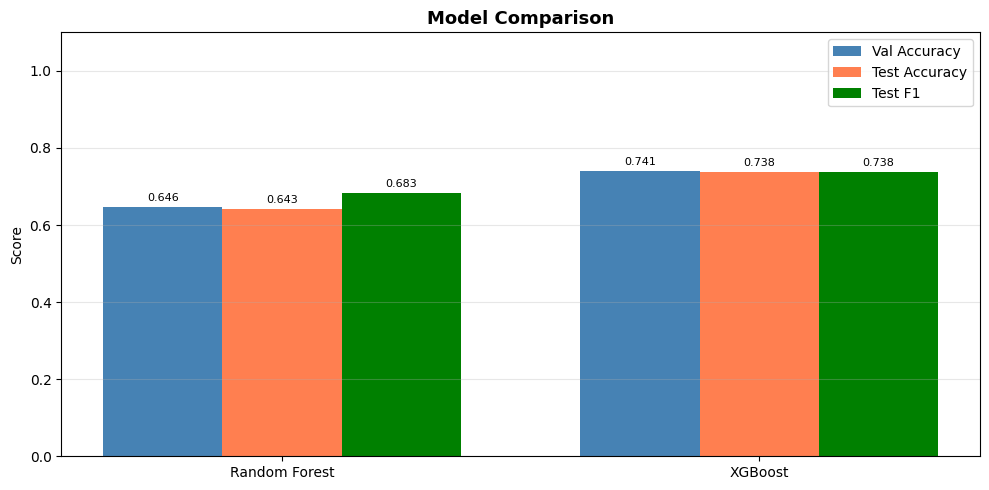


Best model: XGBoost


In [ ]:
# Test set evaluation for both
rf_test_pred  = rf.predict(X_test)
xgb_test_pred = xgb.predict(X_test)

rf_test_acc  = accuracy_score(y_test, rf_test_pred)
xgb_test_acc = accuracy_score(y_test, xgb_test_pred)
rf_test_f1   = f1_score(y_test, rf_test_pred,  average='weighted')
xgb_test_f1  = f1_score(y_test, xgb_test_pred, average='weighted')

# Summary table
import pandas as pd
results = pd.DataFrame({    
    'Model'       : ['Random Forest', 'XGBoost'],
    'Val Accuracy': [rf_val_acc,  xgb_val_acc],
    'Test Accuracy': [rf_test_acc, xgb_test_acc],
    'Test F1'     : [rf_test_f1,  xgb_test_f1],
})
print(results.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(2)
width = 0.25
ax.bar(x - width, [rf_val_acc,  xgb_val_acc],  width, label='Val Accuracy',  color='steelblue')
ax.bar(x,         [rf_test_acc, xgb_test_acc], width, label='Test Accuracy', color='coral')
ax.bar(x + width, [rf_test_f1,  xgb_test_f1],  width, label='Test F1',       color='green')
ax.set_xticks(x)
ax.set_xticklabels(['Random Forest', 'XGBoost'])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Pick best model
best_model = rf if rf_test_acc >= xgb_test_acc else xgb
best_name  = 'Random Forest' if rf_test_acc >= xgb_test_acc else 'XGBoost'
best_preds = rf_test_pred if rf_test_acc >= xgb_test_acc else xgb_test_pred
print(f"\nBest model: {best_name}")

### Confusion matrix (top 20 diseases)

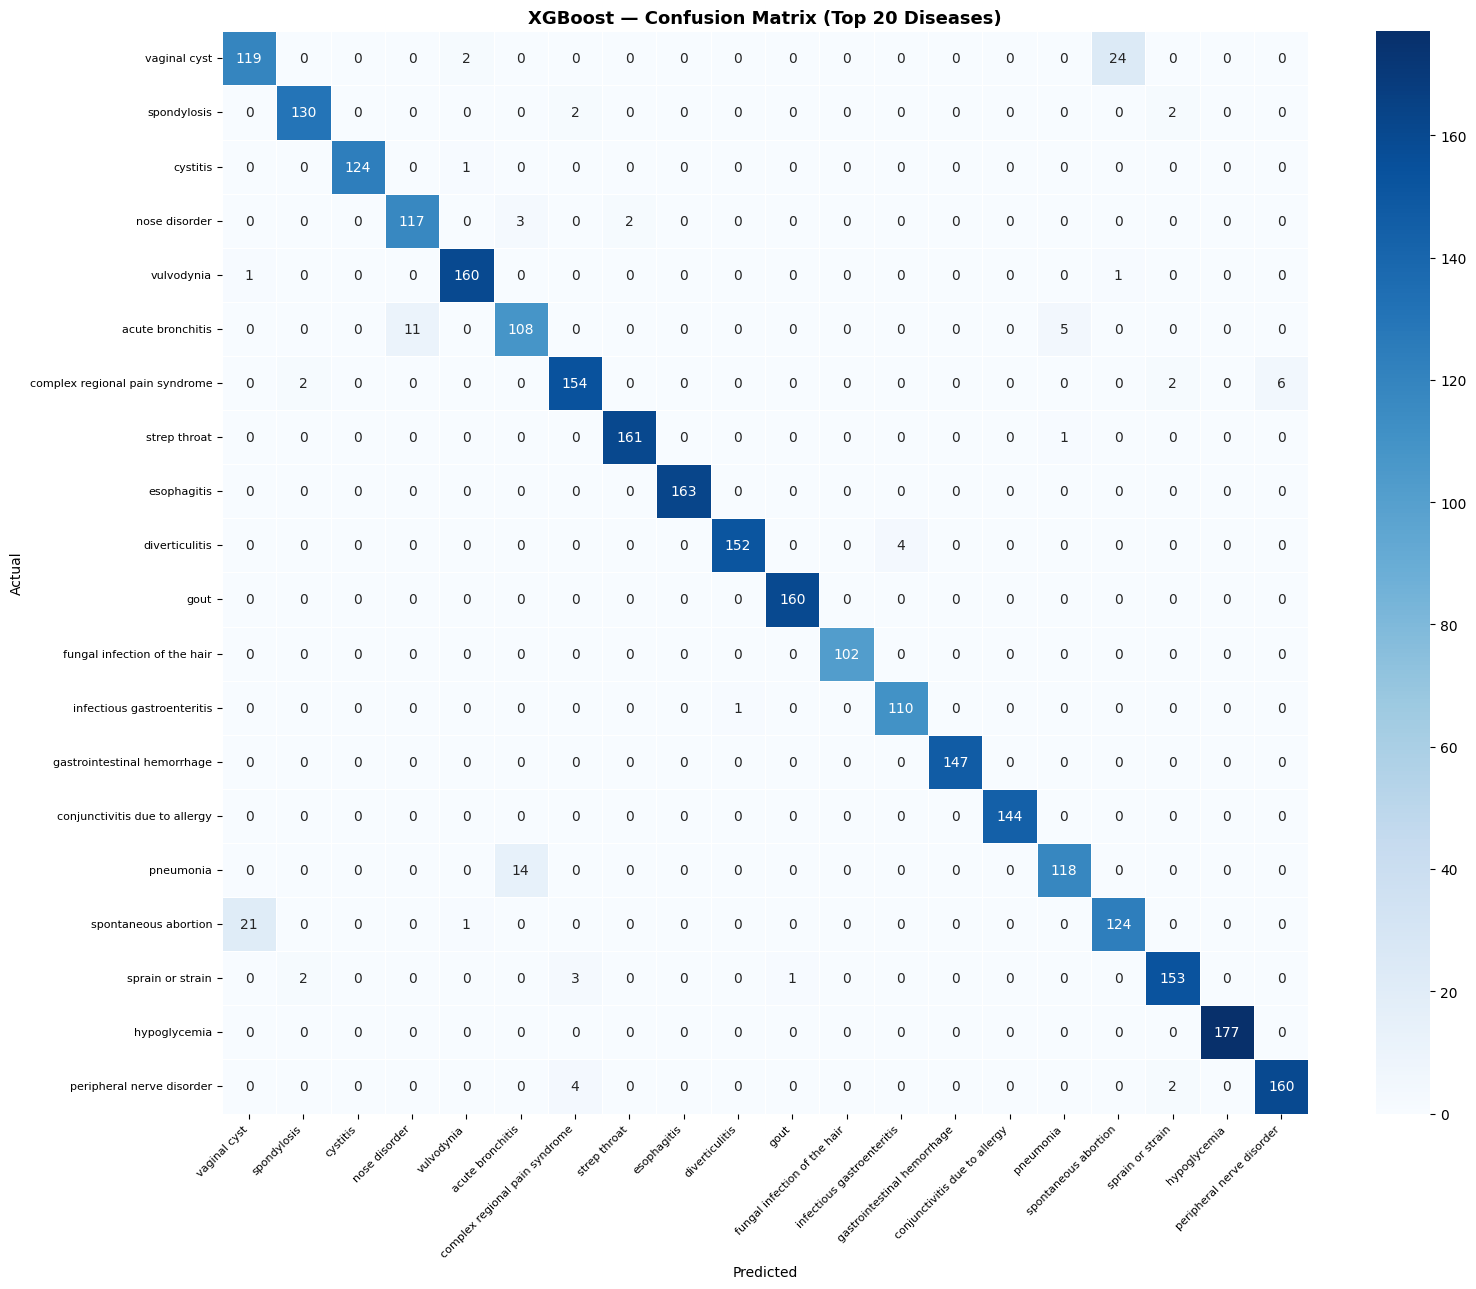

In [5]:
# Full confusion matrix is 700+ x 700+ — show top 20 diseases only
top20 = pd.Series(y_test).value_counts().head(20).index.tolist()
mask  = np.isin(y_test, top20)

cm = confusion_matrix(y_test[mask], best_preds[mask], labels=top20)
top20_names = [disease_names[i] for i in top20]

plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top20_names, yticklabels=top20_names,
            linewidths=0.5)
plt.title(f'{best_name} — Confusion Matrix (Top 20 Diseases)',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature importance (top 25 symptoms)

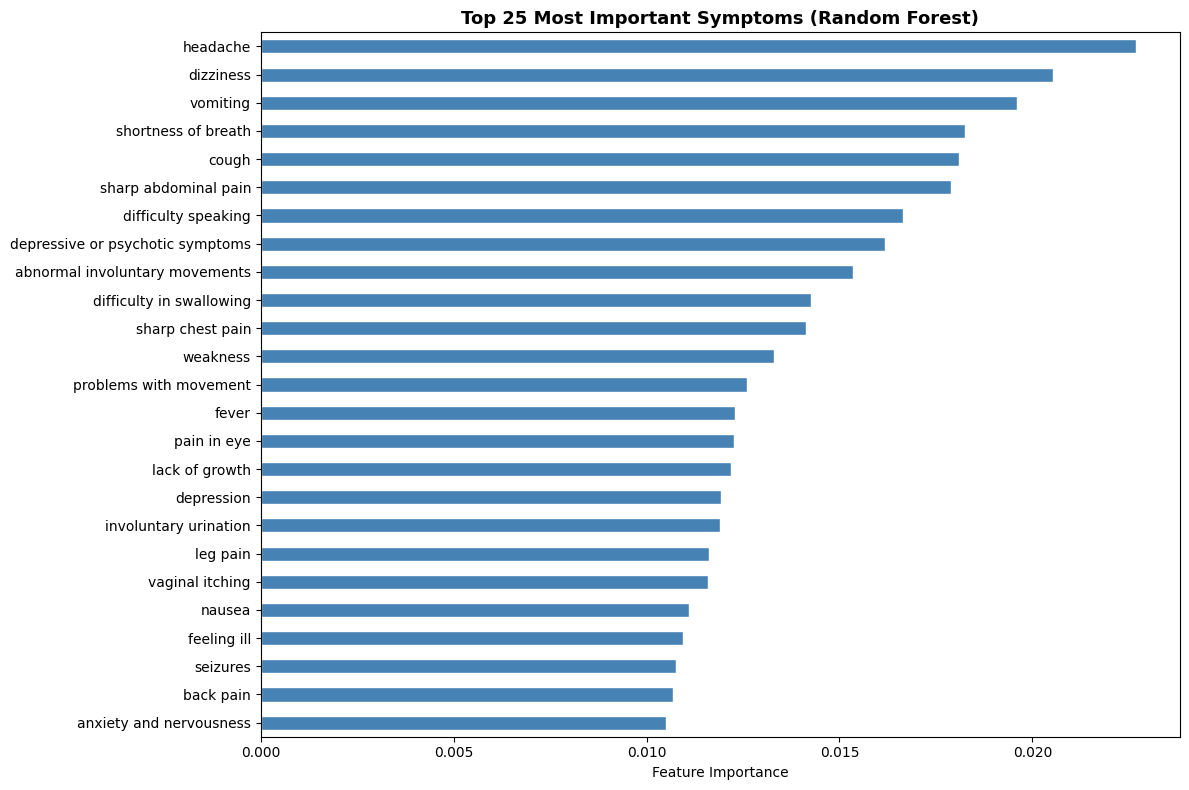

Top 10 most important symptoms:
headache                            0.022691
dizziness                           0.020529
vomiting                            0.019608
shortness of breath                 0.018250
cough                               0.018087
sharp abdominal pain                0.017882
difficulty speaking                 0.016635
depressive or psychotic symptoms    0.016170
abnormal involuntary movements      0.015351
difficulty in swallowing            0.014261


In [6]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
feat_imp.head(25).plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 25 Most Important Symptoms (Random Forest)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 most important symptoms:")
print(feat_imp.head(10).to_string())

### Save models

In [7]:
with open('medisense_preprocessed.pkl', 'rb') as f:
    data = pickle.load(f)

data['rf_model']  = rf
data['xgb_model'] = xgb
data['best_model'] = best_model
data['best_name']  = best_name

with open('medisense_preprocessed.pkl', 'wb') as f:
    pickle.dump(data, f)

print(f"Models saved ✓")
print(f"Best model : {best_name}")
print(f"Test Accuracy: {max(rf_test_acc, xgb_test_acc)*100:.2f}%")

Models saved ✓
Best model : XGBoost
Test Accuracy: 73.79%


In [8]:
# Make sure both models were trained on the same data
print("Data used for both models:")
print(f"  X_train_s shape : {X_train_s.shape}")
print(f"  y_train_s unique classes: {len(np.unique(y_train_s))}")
print(f"  X_val shape     : {X_val.shape}")
print(f"  X_test shape    : {X_test.shape}")

# Final comparison
print("\nFinal Model Comparison:")
print(f"  Random Forest → Val: {rf_val_acc*100:.2f}% | Test: {accuracy_score(y_test, rf.predict(X_test))*100:.2f}%")
print(f"  XGBoost       → Val: {xgb_val_acc*100:.2f}% | Test: {accuracy_score(y_test, xgb.predict(X_test))*100:.2f}%")

Data used for both models:
  X_train_s shape : (50000, 146)
  y_train_s unique classes: 677
  X_val shape     : (36977, 146)
  X_test shape    : (36977, 146)

Final Model Comparison:


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.5s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    5.4s finished


  Random Forest → Val: 64.62% | Test: 64.27%
  XGBoost       → Val: 74.08% | Test: 73.79%


### Set XGBoost as your final model

In [9]:
best_model = xgb
best_name  = 'XGBoost'
best_preds = xgb.predict(X_test)
best_test_acc = accuracy_score(y_test, best_preds)

print(f"Selected model: {best_name}")
print(f"Test Accuracy : {best_test_acc*100:.2f}%")

Selected model: XGBoost
Test Accuracy : 73.79%


### Retraining the lightWeight XGboost

In [1]:
import pickle
import numpy as np
from xgboost import XGBClassifier
from sklearn.utils import resample
from sklearn.metrics import accuracy_score
import os

# Load data
with open('medisense_preprocessed.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
y_train = data['y_train']
X_val   = data['X_val']
X_test  = data['X_test']
y_val   = data['y_val']
y_test  = data['y_test']
le      = data['label_encoder']
feature_names = data['feature_names']

# Sample down to 30k for lighter model
X_s, y_s = resample(X_train, y_train, n_samples=30000,
                     random_state=42, stratify=y_train)

print("Training lightweight model for deployment...")
xgb_lite = XGBClassifier(
    n_estimators=50,        # 50 trees instead of 100
    max_depth=5,            # shallower trees
    learning_rate=0.15,
    subsample=0.8,
    colsample_bytree=0.6,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=2,
    verbosity=1
)
xgb_lite.fit(X_s, y_s, eval_set=[(X_val, y_val)], verbose=25)

# Check accuracy tradeoff
val_acc  = accuracy_score(y_val,  xgb_lite.predict(X_val))
test_acc = accuracy_score(y_test, xgb_lite.predict(X_test))
print(f"\nLite model — Val: {val_acc*100:.2f}% | Test: {test_acc*100:.2f}%")

# Save in native format
xgb_lite.save_model('xgb_model_lite.json')
print(f"Size: {os.path.getsize('xgb_model_lite.json')/1e6:.1f} MB")

/home/sunbeam/.local/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/sunbeam/.local/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/sunbeam/.local/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.8.0 when using version

Training lightweight model for deployment...
[0]	validation_0-mlogloss:5.05250
[25]	validation_0-mlogloss:1.60399
[49]	validation_0-mlogloss:1.24538

Lite model — Val: 70.24% | Test: 69.76%
Size: 39.9 MB


###

### Packaging everything for deployment

In [2]:
deploy_data = {
    'X_val'        : X_val,
    'X_test'       : X_test,
    'y_val'        : y_val,
    'y_test'       : y_test,
    'feature_names': feature_names,
    'label_encoder': le,
    'disease_names': list(le.classes_),
}

with open('medisense_deploy.pkl', 'wb') as f:
    pickle.dump(deploy_data, f)

print(f"medisense_deploy.pkl : {os.path.getsize('medisense_deploy.pkl')/1e6:.1f} MB")
print(f"xgb_model_lite.json  : {os.path.getsize('xgb_model_lite.json')/1e6:.1f} MB")
print(f"rag_knowledge.pkl    : {os.path.getsize('rag_knowledge.pkl')/1e6:.1f} MB")
print(f"nlp_artifacts.pkl    : {os.path.getsize('nlp_artifacts.pkl')/1e6:.1f} MB")

medisense_deploy.pkl : 87.6 MB
xgb_model_lite.json  : 39.9 MB
rag_knowledge.pkl    : 4.3 MB
nlp_artifacts.pkl    : 0.0 MB


In [3]:
# Minimal deploy pickle — only what app.py actually needs at runtime
deploy_minimal = {
    'feature_names': feature_names,
    'label_encoder': le,
    'disease_names': list(le.classes_),
}

with open('medisense_deploy.pkl', 'wb') as f:
    pickle.dump(deploy_minimal, f)

print(f"medisense_deploy.pkl : {os.path.getsize('medisense_deploy.pkl')/1e6:.1f} MB")

medisense_deploy.pkl : 0.0 MB
